In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Veri setini kodun içine gömüyoruz
data = {
    'Customer ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Gender': ['Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'Age': [29, 34, 43, 30, 24, 38, 27, 52, 31, 45],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Miami', 'New York', 'Los Angeles', 'Chicago', 'Miami', 'Houston'],
    'Product Category': ['Electronics', 'Clothing', 'Home', 'Electronics', 'Clothing', 'Home', 'Electronics', 'Clothing', 'Home', 'Electronics'],
    'Total Spend': [1200, 150, 600, 800, 200, 450, 950, 120, 700, 1100]
}

df = pd.DataFrame(data)
print("Veri seti başarıyla oluşturuldu!")
df.head() # Tabloyu kontrol et

Veri seti başarıyla oluşturuldu!


,Customer ID,Gender,Age,City,Product Category,Total Spend
0,1,Female,29,New York,Electronics,1200
1,2,Male,34,Los Angeles,Clothing,150
2,3,Female,43,Chicago,Home,600
3,4,Male,30,Houston,Electronics,800
4,5,Female,24,Miami,Clothing,200


In [5]:
# Boş bir grafik oluştur
G = nx.Graph()

for index, row in df.iterrows():
    musteri = f"Musteri_{row['Customer ID']}"
    urun = row['Product Category']
    
    # Düğümleri (Noktaları) ekle
    G.add_node(musteri, type='customer', gender=row['Gender'], age=row['Age'])
    G.add_node(urun, type='product')
    
    # Bağlantıyı (Çizgiyi) kur
    G.add_edge(musteri, urun, weight=row['Total Spend'])

print(f"Sosyal Ağ Hazır! Düğüm sayısı: {G.number_of_nodes()}, Bağlantı sayısı: {G.number_of_edges()}")

Sosyal Ağ Hazır! Düğüm sayısı: 13, Bağlantı sayısı: 10


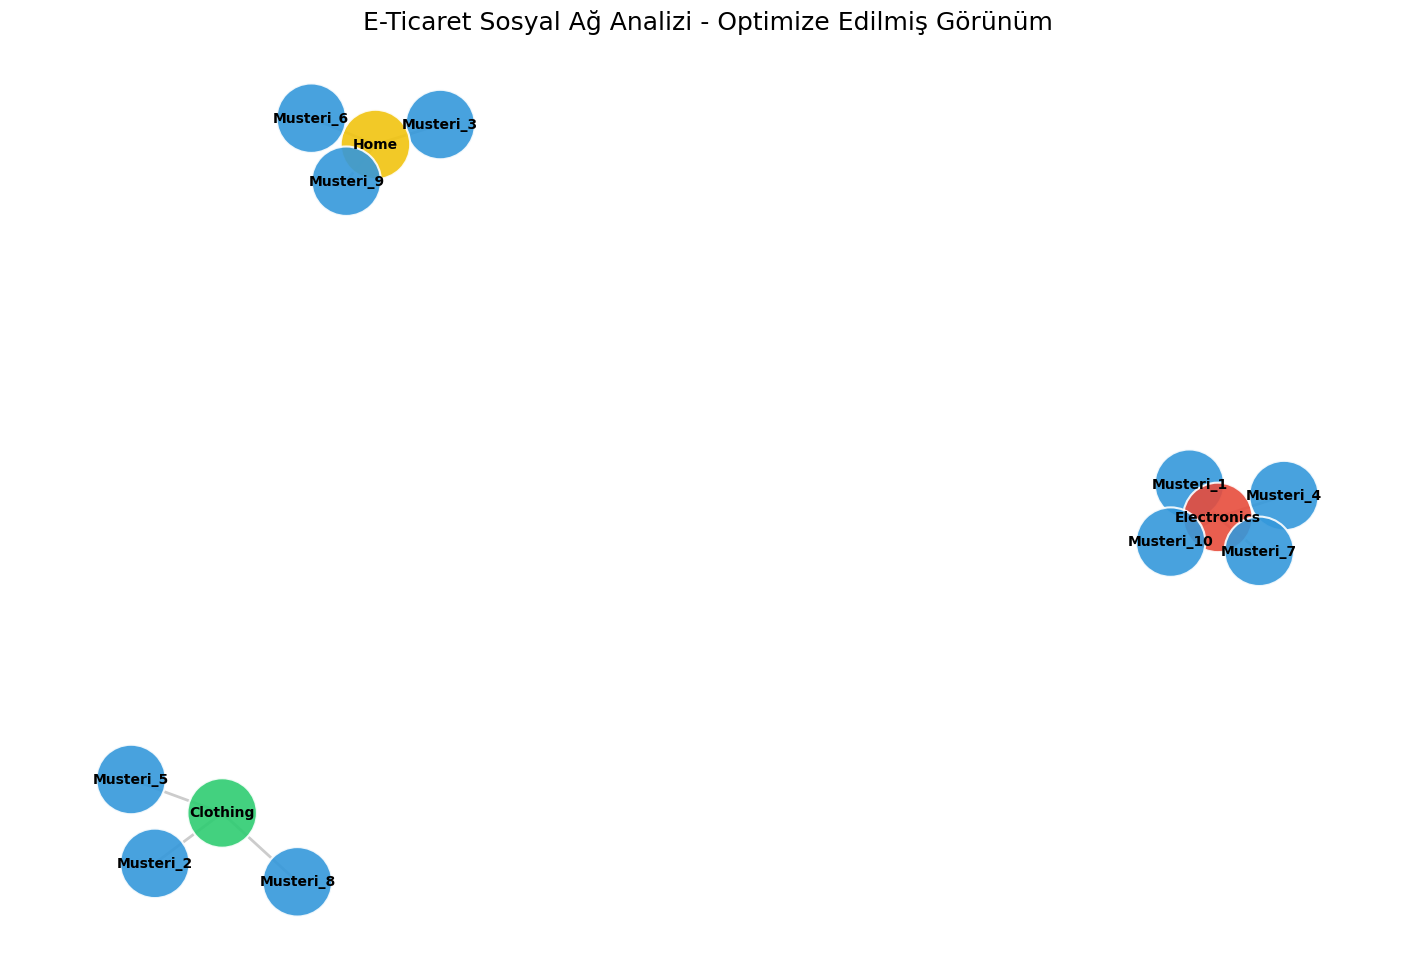

In [13]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Alanı iyice genişletelim
plt.figure(figsize=(18, 12))

# 2. SİHİRLİ AYAR: k değerini 3.0 yapıyoruz (Toplar birbirinden iyice kaçsın)
# seed=42 kalsın ki grafik her seferinde sağa sola zıplamasın
pos = nx.spring_layout(G, k=3.0, seed=42, iterations=100)

# 3. Renkler aynı kalsın (Senin sevdiğin düzen)
node_colors = []
for node in G.nodes():
    if G.nodes[node].get('type') == 'product':
        if node == 'Electronics': node_colors.append('#e74c3c') # Kırmızı
        elif node == 'Clothing': node_colors.append('#2ecc71')  # Yeşil
        elif node == 'Home': node_colors.append('#f1c40f')      # Sarı
        else: node_colors.append('#9b59b6')
    else:
        node_colors.append('#3498db') # Müşteriler mavi

# 4. Çizim - Düğümleri biraz küçültelim (2000 yaptık) 
# Böylece Electronics etrafındaki 5-6 kişi birbirini ezmez
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9, edgecolors='white', linewidths=1.5)

# 5. Çizgileri biraz daha ince ve şeffaf yapalım ki yazıları kapatmasın
nx.draw_networkx_edges(G, pos, width=2, alpha=0.2, edge_color='black')

# 6. Yazı boyutunu hafif küçültelim (10 yaptık)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("E-Ticaret Sosyal Ağ Analizi - Optimize Edilmiş Görünüm", fontsize=18)
plt.axis('off')
plt.show()

In [8]:
# Hangi ürün daha merkezi?
centrality = nx.degree_centrality(G)
# Ürünleri filtrele ve en popülerini bul
products = [n for n in G.nodes if G.nodes[n].get('type') == 'product']
product_scores = {n: centrality[n] for n in products}

print("Ürünlerin Popülerlik Skorları:")
for prod, score in product_scores.items():
    print(f"- {prod}: {score:.2f}")

en_populer = max(product_scores, key=product_scores.get)
print(f"\nSonuç: Bu ağın en önemli düğümü '{en_populer}' ürünüdür.")

Ürünlerin Popülerlik Skorları:
- Electronics: 0.33
- Clothing: 0.25
- Home: 0.25

Sonuç: Bu ağın en önemli düğümü 'Electronics' ürünüdür.
